# TD11: Linguistic laws

## 0. Question

Today, we will answer the following questions:

- Does the Brown corpus follow the rank-frequency pattern predicted by Zipf's law?
- Are frequent words in the Brown corpus shorter on average than less frequent words (Zipf's law of abbreviation)?

We will use the Brown corpus from NLTK, a classic balanced corpus of written English, and we will work through the analysis step by step.

In [53]:
import nltk # corpus access
import numpy as np # numerical computation
import pandas as pd # data-frame manipulation
import matplotlib.pyplot as plt # plotting
import seaborn as sns # plotting
from nltk.corpus import brown # Brown corpus
from scipy.optimize import curve_fit # fitting the curve
from sklearn.metrics import r2_score # coefficient of determination

sns.set(context='paper', style='ticks',
        font_scale=1, palette='colorblind')

If the Brown corpus is not installed in your environment yet, run the following cell:

In [64]:
try:
    brown.ensure_loaded()
except LookupError:
    nltk.download('brown')
    brown.ensure_loaded()

## 1. Data

### 1.1. Loading the Brown corpus

Let's start by loading all word tokens from the Brown corpus.

In [65]:
tokens = brown.words()
len(tokens)

1161192

What do the first tokens look like?

In [4]:
tokens[:40]

['The',
 'Fulton',
 'County',
 'Grand',
 'Jury',
 'said',
 'Friday',
 'an',
 'investigation',
 'of',
 "Atlanta's",
 'recent',
 'primary',
 'election',
 'produced',
 '``',
 'no',
 'evidence',
 "''",
 'that',
 'any',
 'irregularities',
 'took',
 'place',
 '.',
 'The',
 'jury',
 'further',
 'said',
 'in',
 'term-end',
 'presentments',
 'that',
 'the',
 'City',
 'Executive',
 'Committee',
 ',',
 'which',
 'had']

### 1.2. Cleaning the corpus

For this practical, we will only keep alphabetic tokens and we will lowercase everything. This removes punctuation and makes frequencies easier to interpret. 

Convert tokens to lowercase and keep only alphabetic tokens.

In [5]:
words = [token.lower() for token in tokens if token.isalpha()]
len(words)

981716

Let's inspect the cleaned tokens.

In [6]:
words[:40]

['the',
 'fulton',
 'county',
 'grand',
 'jury',
 'said',
 'friday',
 'an',
 'investigation',
 'of',
 'recent',
 'primary',
 'election',
 'produced',
 'no',
 'evidence',
 'that',
 'any',
 'irregularities',
 'took',
 'place',
 'the',
 'jury',
 'further',
 'said',
 'in',
 'presentments',
 'that',
 'the',
 'city',
 'executive',
 'committee',
 'which',
 'had',
 'charge',
 'of',
 'the',
 'election',
 'deserves',
 'the']

How many cleaned word tokens and unique words do we have?

In [7]:
len(words), len(set(words))

(981716, 40234)

### 1.3. Building a frequency table

Now we will count how often each word type occurs in the corpus.

In [66]:
freq_table = (
    pd.Series(words, name='word')
      .value_counts()
      .rename_axis('word')
      .reset_index(name='frequency')
)

freq_table.head(10)

,word,frequency
0,the,69971
1,of,36412
2,and,28853
3,to,26158
4,a,23195
5,in,21337
6,that,10594
7,is,10109
8,was,9815
9,he,9548


Let's add the rank of each word and its length in letters. Name the columns `rank` and `length` respectively.

In [68]:
freq_table['rank'] = freq_table.index + 1
freq_table['length'] = freq_table['word'].str.len()

freq_table.head(10)

,word,frequency,rank,length
0,the,69971,1,3
1,of,36412,2,2
2,and,28853,3,3
3,to,26158,4,2
4,a,23195,5,1
5,in,21337,6,2
6,that,10594,7,4
7,is,10109,8,2
8,was,9815,9,3
9,he,9548,10,2


## 2. Zipf's law

### 2.1. A first look at the rank-frequency distribution

We first plot the 100 most frequent words on the original scale.

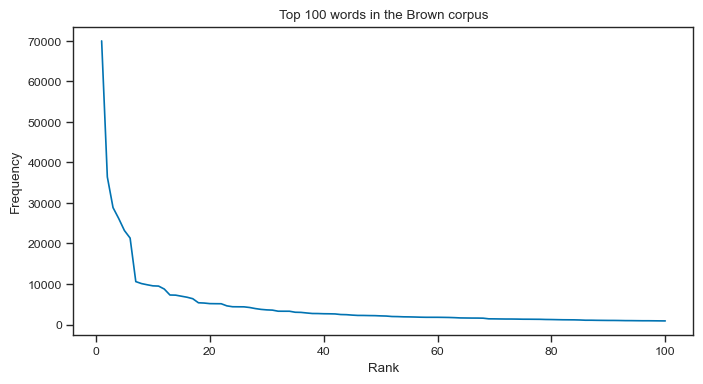

In [10]:
top_100 = freq_table.head(100)

plt.figure(figsize=(8, 4))
plt.plot(top_100['rank'], top_100['frequency'])
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Top 100 words in the Brown corpus')
plt.show()

The decay is easier to see on log-log axes.

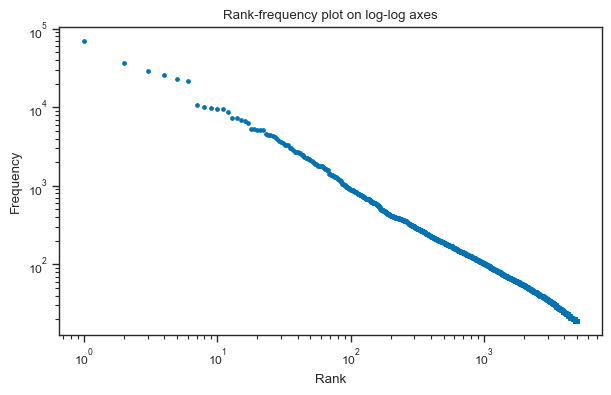

In [11]:
top_5000 = freq_table.head(5000)

plt.figure(figsize=(7, 4))
plt.loglog(top_5000['rank'], top_5000['frequency'], '.')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Rank-frequency plot on log-log axes')
plt.show()

### 2.2. Checking rank x frequency

A simple rule-of-thumb version of Zipf's law says that `rank x frequency` should be roughly stable for a large part of the distribution.

In [12]:
zipf_check = freq_table.head(1000).copy()
zipf_check['rank_x_frequency'] = zipf_check['rank'] * zipf_check['frequency']

zipf_check[['rank', 'frequency', 'rank_x_frequency']].head(10)

,rank,frequency,rank_x_frequency
0,1,69971,69971
1,2,36412,72824
2,3,28853,86559
3,4,26158,104632
4,5,23195,115975
5,6,21337,128022
6,7,10594,74158
7,8,10109,80872
8,9,9815,88335
9,10,9548,95480


Let's summarize this quantity.

In [13]:
zipf_check['rank_x_frequency'].describe()

count      1000.000000
mean      95652.183000
std        5816.101146
min       69971.000000
25%       91271.250000
50%       96131.000000
75%      100502.500000
max      128022.000000
Name: rank_x_frequency, dtype: float64

And now let's plot it.

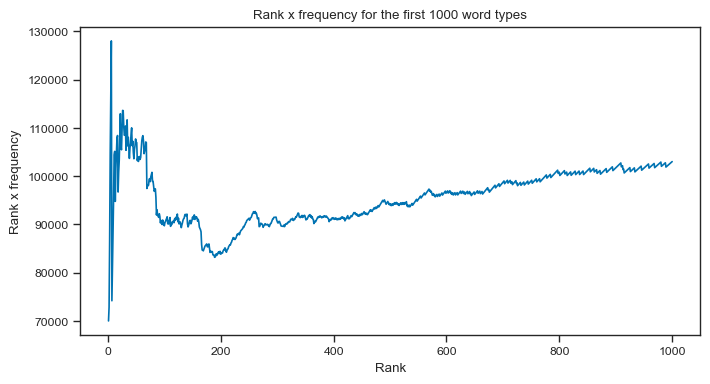

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(zipf_check['rank'], zipf_check['rank_x_frequency'])
plt.xlabel('Rank')
plt.ylabel('Rank x frequency')
plt.title('Rank x frequency for the first 1000 word types')
plt.show()

### 2.3. Fitting Zipf's law

To keep the fit readable, we will focus on the 2000 most frequent words. We first fit the basic power-law model

$$f(r) = A / r^b$$

In [34]:
fit_data = freq_table.head(2000).copy()

ranks = fit_data['rank'].to_numpy(dtype=float)
frequencies = fit_data['frequency'].to_numpy(dtype=float)

Frequencies are stored as counts, let's convert them to relative frequencies by dividing by the total number of tokens.

In [36]:
relative_frequencies = frequencies / frequencies.sum()

Now let's define the original Zipf's law:

In [37]:
def zipf_basic(r, A, b):
    return A / (r ** b)

Let's fit the original Zipf's law:

In [38]:
params, _ = curve_fit(
    zipf_basic,
    ranks,
    relative_frequencies,
    p0=(frequencies[0], 1.0),
    bounds=(0, np.inf),
    maxfev=10000
)

A_basic, b_basic = params
basic_prediction = zipf_basic(ranks, A_basic, b_basic)

# keep these for the next cell
log_ranks = np.log(ranks)
log_frequencies = np.log(frequencies)

print(f"Basic model: f(r) = {A_basic:.1f} / r^{b_basic:.2f}")

Basic model: f(r) = 0.1 / r^0.88


Let's now plot the preidctions:

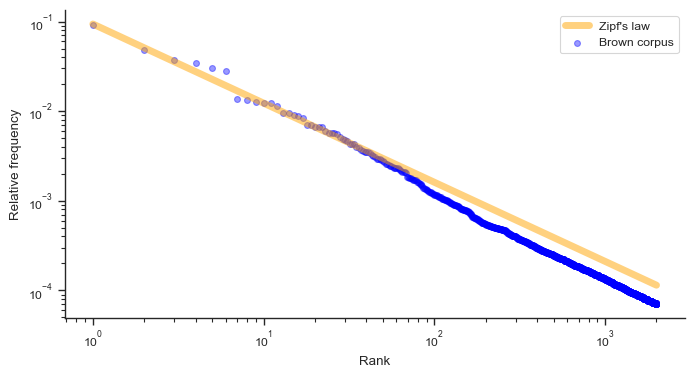

In [51]:
plt.figure(figsize=(8, 4))

# fitted curve
plt.plot(ranks, basic_prediction, 
         label="Zipf's law", color='orange',
         linewidth=5, alpha=0.5)

# observed points as scatter
plt.scatter(ranks, relative_frequencies, 
            alpha=0.4, s=18, label='Brown corpus',
            color='blue')

# apply symlog scales after plotting
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Rank')
plt.ylabel('Relative frequency')
sns.despine()
plt.legend()
plt.show()

Now let's compute the coefficient of determination $R^2$ for the original Zipf's law:

In [54]:
r2_basic = r2_score(relative_frequencies, basic_prediction)
print(f"R² (basic Zipf model): {r2_basic:.4f}")

R² (basic Zipf model): 0.9849


Now let's try the Zipf-Mandelbrot law, which adds two parameters to the original Zipf's law:

$$f(r) = A / (r + c)^b$$

In [61]:
def zipf_mandelbrot(r, A, b, c):
    return A / (r + c) ** b

params, _ = curve_fit(
    zipf_mandelbrot,
    ranks,
    relative_frequencies,
    bounds=(0, np.inf),
    maxfev=10000
)

A_zm, b_zm, c_zm = params
zm_prediction = zipf_mandelbrot(ranks, A_zm, b_zm, c_zm)

# keep these for the next cell
log_ranks = np.log(ranks)
log_frequencies = np.log(frequencies)

print(f"Zipf-Mandelbrot: f(r) = {A_zm:.1f} / (r + {c_zm:.2f})^{b_zm:.2f}")

Zipf-Mandelbrot: f(r) = 0.1 / (r + 0.53)^1.00


Now let's plot the Zipf-Mandelbrot predictions:

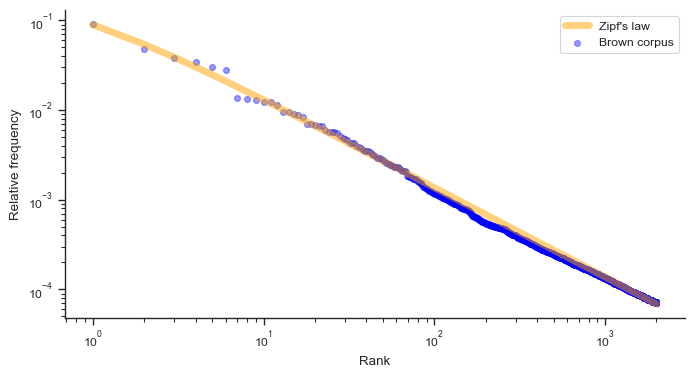

In [62]:
plt.figure(figsize=(8, 4))

# fitted curve
plt.plot(ranks, zm_prediction, 
         label="Zipf's law", color='orange',
         linewidth=5, alpha=0.5)

# observed points as scatter
plt.scatter(ranks, relative_frequencies, 
            alpha=0.4, s=18, label='Brown corpus',
            color='blue')

# apply symlog scales after plotting
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Rank')
plt.ylabel('Relative frequency')
sns.despine()
plt.legend()
plt.show()

Let's compute the $R^2$ for the Zipf-Mandelbrot law:

In [63]:
r2_zm = r2_score(relative_frequencies, zm_prediction)
print(f"R² (Zipf-Mandelbrot model): {r2_zm:.4f}")

R² (Zipf-Mandelbrot model): 0.9894


Which model fits better? Why do you think that is?

## 3. Zipf's law of abbreviation

### 3.1. Preparing the data

For this part, we will use the same frequency table, but we will focus on words that occur at least 5 times. This makes the pattern less noisy.

In [19]:
abbreviation_data = freq_table.query('frequency >= 5').copy()
abbreviation_data.shape

(13366, 4)

Let's inspect the beginning of this table.

In [20]:
abbreviation_data[['word', 'frequency', 'length']].head(10)

,word,frequency,length
0,the,69971,3
1,of,36412,2
2,and,28853,3
3,to,26158,2
4,a,23195,1
5,in,21337,2
6,that,10594,4
7,is,10109,2
8,was,9815,3
9,he,9548,2


### 3.2. Visual inspection

We can now plot word length against frequency. Since frequency is very skewed, we will use a logarithmic x-axis.

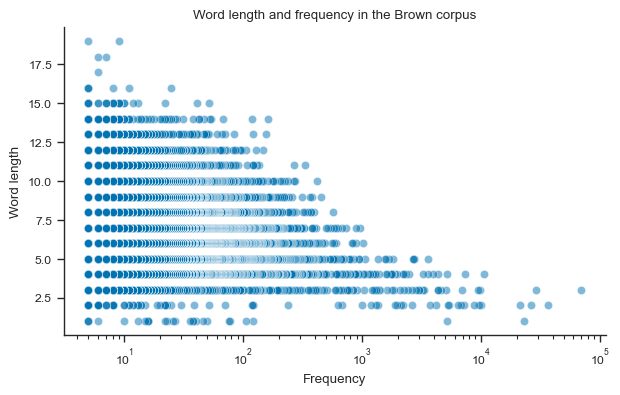

In [71]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=abbreviation_data, 
                x='frequency', y='length', alpha=0.5, s=35)
plt.xscale('log')
plt.xlabel('Frequency')
plt.ylabel('Word length')
plt.title('Word length and frequency in the Brown corpus')
sns.despine()
plt.show()

### 3.3. A permutation test

A simple way to test the Zipf's law of abbreviation is to compare the observed value of

$$\sum_i \text{length}_i \times \text{frequency}_i$$

against a null distribution where word lengths are randomly reassigned to frequencies.

In [72]:
lengths = abbreviation_data['length'].to_numpy(dtype=float)
frequencies = abbreviation_data['frequency'].to_numpy(dtype=float)

observed = np.sum(lengths * frequencies)
observed

4227912.0

Let's build the null distribution by shuffling the lengths 2000 times.

In [74]:
np.random.seed(42)
null_statistics = np.empty(2000)

for i in range(len(null_statistics)):
    shuffled_lengths = np.random.permutation(lengths)
    null_statistics[i] = np.sum(shuffled_lengths * frequencies)

Finally, let's visualize the null distribution.

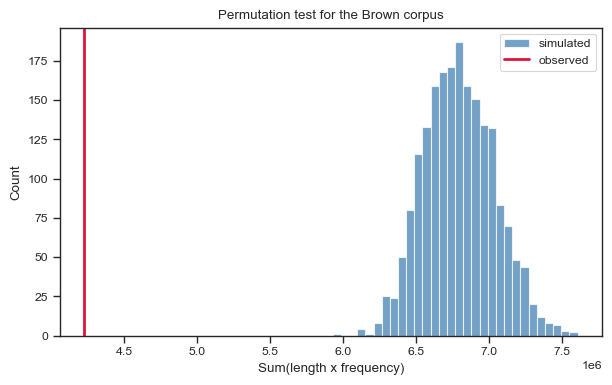

In [77]:
plt.figure(figsize=(7, 4))
plt.hist(null_statistics, bins=30, alpha=0.75, color='steelblue',
         label='simulated')
plt.axvline(observed, color='crimson', linewidth=2, label='observed')
plt.xlabel('Sum(length x frequency)')
plt.ylabel('Count')
plt.title('Permutation test for the Brown corpus')
plt.legend()
plt.show()

## 4. Discussion

- The Brown corpus shows the familiar steep decay of frequency with rank.
- On log-log axes, the rank-frequency relationship is close to linear over a substantial part of the distribution.
- The shifted Zipf model often gives a slightly better fit than the plain power-law model.
- In the abbreviation test, an unusually small observed `length x frequency` sum supports the idea that frequent words tend to be shorter.

This practical uses only a simple workflow, but the same logic can be extended to compare genres, corpora, or languages.